In [1]:
#Tratamiento de datos
import pandas as pd

#configuracion de visualizacion
pd.set_option('display.max_columns',None)

#exploracion de archivos
import sys
sys.path.append('../')

#funciones personalizadas
from SRC import sp_nulos as sn
from SRC import sp_visualizaciones_eda as sv

#visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_no_nulos=pd.read_csv("../datos/df_data_no_nulos.csv", parse_dates=['date_contact', 'dt_customer'])

# DISTRIBUCION DE COLUMNAS CATEGORICAS

### VISUALIZACION DE FRECUENCIAS

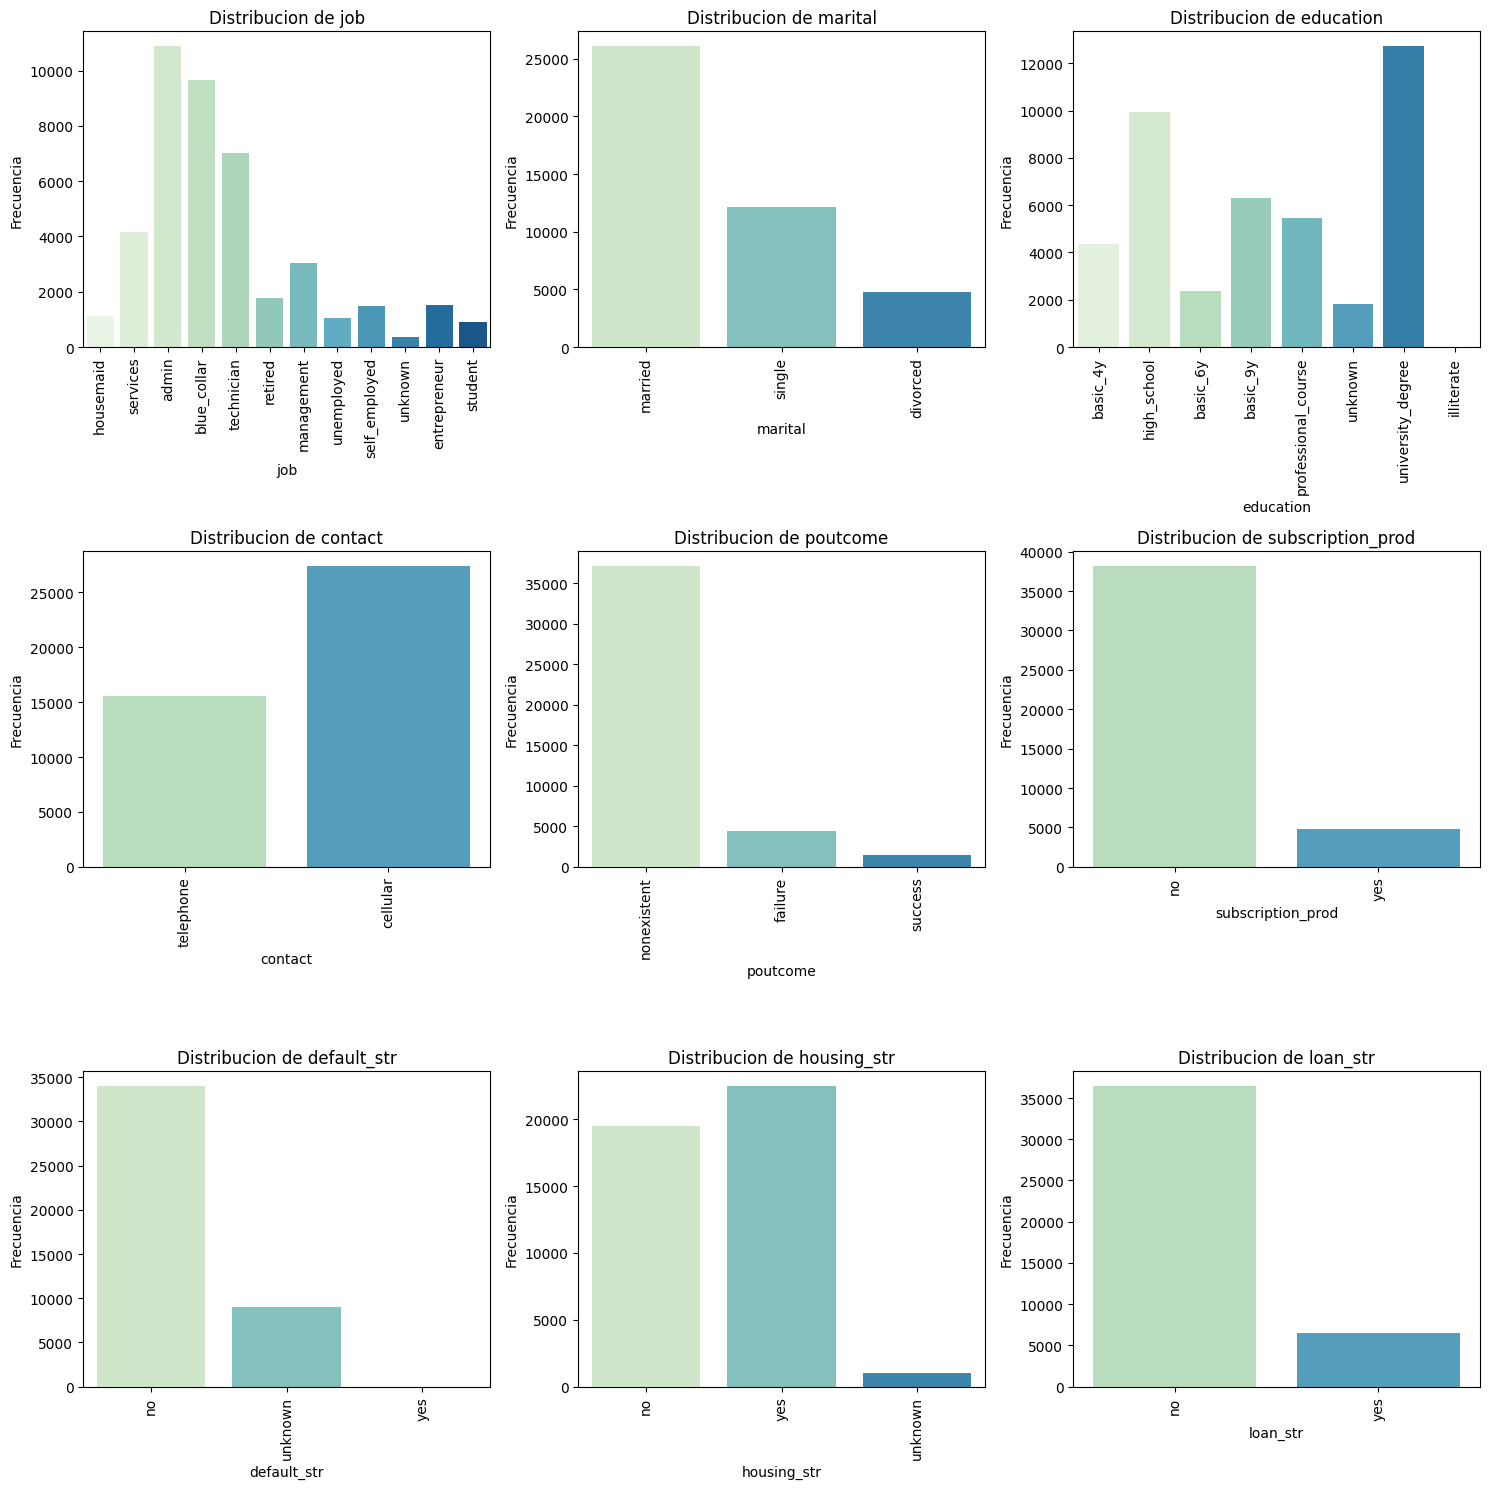

In [3]:
sv.subplot_col_cat(df_no_nulos.drop(columns=['id']))

### CALCULO DE FRECUENCIAS

In [4]:

for col in df_no_nulos.select_dtypes(include='object').columns:
    print(col.upper())
    print(df_no_nulos[col].value_counts()/df_no_nulos.shape[0]*100)
    print ('------------------------')

JOB
job
admin            25.286047
blue_collar      22.451163
technician       16.339535
services          9.679070
management        7.093023
retired           4.162791
entrepreneur      3.539535
self_employed     3.462791
housemaid         2.611628
unemployed        2.472093
student           2.100000
unknown           0.802326
Name: count, dtype: float64
------------------------
MARITAL
marital
married     60.660465
single      28.151163
divorced    11.188372
Name: count, dtype: float64
------------------------
EDUCATION
education
university_degree      29.586047
high_school            23.081395
basic_9y               14.672093
professional_course    12.737209
basic_4y               10.130233
basic_6y                5.548837
unknown                 4.202326
illiterate              0.041860
Name: count, dtype: float64
------------------------
CONTACT
contact
cellular     63.711628
telephone    36.288372
Name: count, dtype: float64
------------------------
POUTCOME
poutcome
nonexisten

**job** La mayoria de los clientes contactados trabajan en sectores administrativos (25%), obreros o industriales (22%) y tecnicos (16%), mientras que colectivos como estudiantes (2%) o desempleados (2.4%) son minoritarios. 

Los bancos tienden a dirigir las campañas a personas con empleo estable y capacidad de ahorro. Profesiones como "retired" o "management" podrían mostrar una mayor propension a contratar productos financieros por su perfil economico.

**marital** Predominan los casados (61%), seguidos de solteros (28%) y divorciados (11%). 

Los casados suelen representar el segmento de clientes con mayor estabilidad financiera y decisiones mas conservadoras, mientras que los solteros pueden mostrar mayor receptividad a nuevos productos. Es un punto interesante para segmentar estrategias de marketing.

**education** Casi un 30% posee título universitario, seguido de formación secundaria (23%) y distintos niveles de educacion basica. Solo un 0.04% son analfabetos (illiterate). 

Un nivel educativo mas alto puede relacionarse con mayor conocimiento financiero y, por tanto, mayor predisposición a comprender y contratar productos bancarios complejos.
El grupo "unknown" (4.2%) puede distorsionar conclusiones.

**contact** El 63.7% fue contactado por móvil y el 36.3% por teléfono fijo. 

Puede reflejar una mayor modernización del canal de contacto. Los clientes contactados por móvil podrían mostrar tasas de éxito mayores, ya que el canal es más directo y personal.

**poutcome** Una gran mayoría (86%) no participó en campañas previas, un 10% tuvo un resultado fallido y solo un 3.3% tuvo éxito. 

Las campañas anteriores no lograron gran conversión, pero los que sí lo hicieron podrían representar un perfil de cliente leal, útil para estrategias de retención.

**subscription_pro** Solo un 11.3% contrató el producto frente a un 88.7% que no lo hizo. 

La campaña tiene una baja tasa de conversión.

**default_str** La gran mayoría no tiene deudas impagadas (79%), aunque hay un 21% de valores desconocidos.

**housing_str** Un 52.3% tiene hipoteca, un 45.3% no y un 2.4% se desconoce.

**Loan_str** Un 15.2% tiene préstamos personales, frente al 84.8% que no.
los clientes sin préstamos activos podrían tener mayor capacidad para invertir o contratar productos financieros.



# DISTRIBUCION DE COLUMNAS NUMERICAS

### VISUALIZACION DE FRECUENCIAS

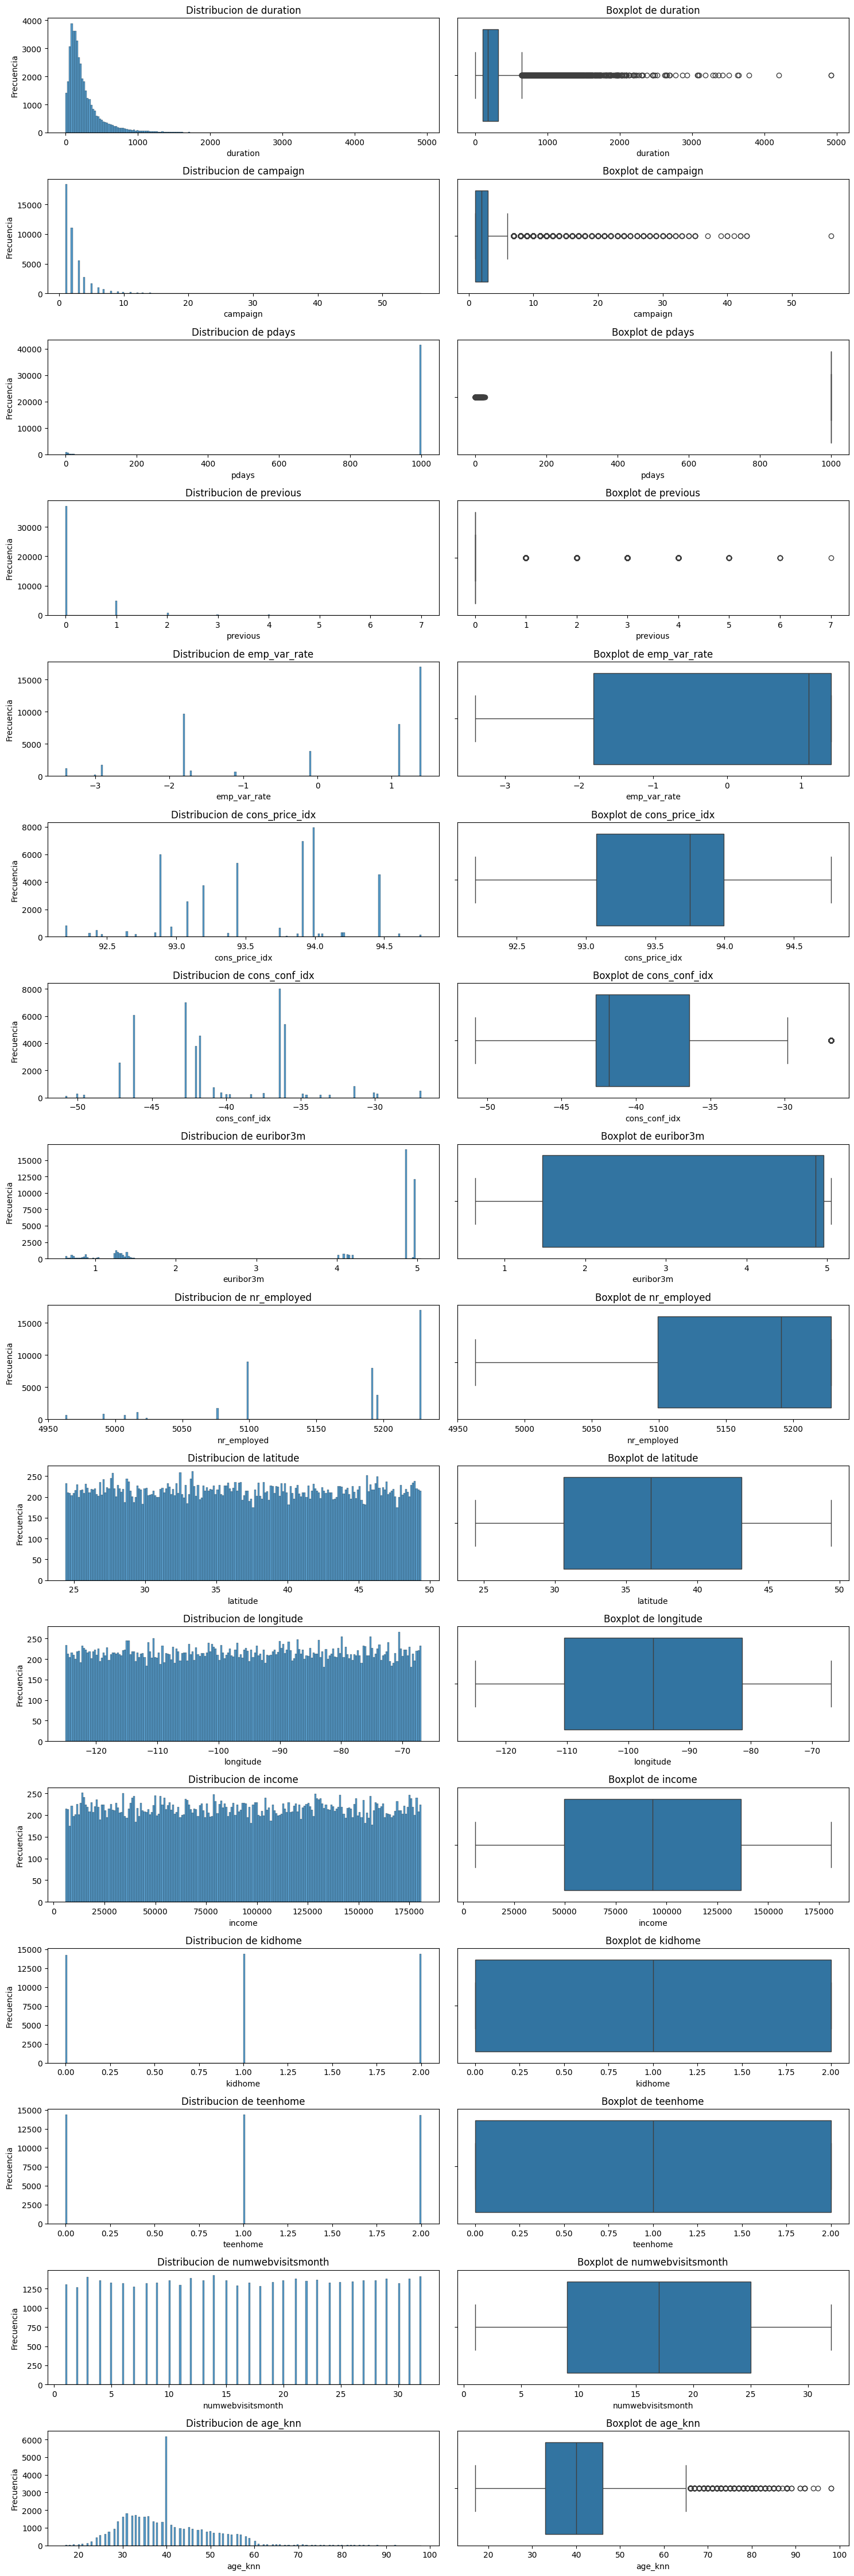

In [5]:
sv.subplot_col_num(df_no_nulos)

In [6]:
df_no_nulos.select_dtypes(include=['int64', 'float64']).describe().T

,count,mean,std,min,25%,50%,75%,max
duration,43000.0,257.739279,258.666033,0.000,102.00000,179.000000,319.00000,4918.000
campaign,43000.0,2.567233,2.772294,1.000,1.00000,2.000000,3.00000,56.000
pdays,43000.0,962.330953,187.260394,0.000,999.00000,999.000000,999.00000,999.000
previous,43000.0,0.174023,0.497366,0.000,0.00000,0.000000,0.00000,7.000
emp_var_rate,43000.0,0.077128,1.573898,-3.400,-1.80000,1.100000,1.40000,1.400
cons_price_idx,43000.0,93.576134,0.576652,92.201,93.07500,93.749000,93.99400,94.767
cons_conf_idx,43000.0,-40.509049,4.637186,-50.800,-42.70000,-41.800000,-36.40000,-26.900
euribor3m,43000.0,3.883541,1.621095,0.634,1.46600,4.857000,4.95900,5.045
nr_employed,43000.0,5166.665860,72.488304,4963.000,5099.00000,5191.000000,5228.00000,5228.000
latitude,43000.0,36.856697,7.225948,24.396,30.61475,36.761000,43.11325,49.384


* **duration** La mayoria de llamadas son cortas. Distribucion sesgada a la derecha. Cola larga con llamadas que llegan hasta los 5000 segundos. Se pueden apreciar ourliers, con llamadas excepcionalmente largas. Los outliers tienen llamadas entre 600 y 700 segundos. Presenta mediana muy baja, que indica que el 50% de llamadas duran menos de 3-4 minutos. Los outliers son llamadas de mas de 600/700 segundos. Las llamadas largas podrian corresponderse con clientes interesados.

* **campaign** Distribucion estremadamente sesgada. La mayoria contactados 1-2 veces y muy pocos mas de 5 veces. Hay casos extremos con hasta 56 contactos. El boxplot indica una mediana de 2 contactos y un 5.82% de outliers (clientes contactados más de 5-6 veces).

* **pdays** la mayoría de los clientes 86% nunca había sido contactada antes.Todo indica que el valor 999 significa que no hubo contacto previo Hay muy pocos casos con otros valores, y un pequeño grupo (3.7%) tuvo contactos hace mucho tiempo. Casi todos los clientes son nuevos.

* **previous** La mayoría de los clientes (unos 35,000) nunca había sido contactada antes (previous = 0), y solo unos pocos tuvieron 1 o más contactos previos. Los que tienen 2 o más se consideran outliers (13.7%), es decir, clientes que ya participaron en varias campañas.Casi todos los clientes son nuevos, y los que aparecen como outliers pueden ser clientes habituales del banco.

* **emp_var_rate** mide la evolución del empleo y muestra cuatro grupos de valores: -3%, -2%, +0.1% y +1.4%, que reflejan diferentes fases económicas (crisis, recuperación y expansión). No tiene outliers y los datos están bien distribuidos.

* **cons_price_idx** mide los precios al consumidor y se mantiene bastante estable entre 92.2 y 94.8, con varios picos que reflejan distintos meses o trimestres. Tiene pocos outliers y poca variación general. Muestra una inflacion controlada.

* **cons_conf_idx** El índice de confianza del consumidor varía entre -50 y +10, con varios picos y sin un patrón fijo, por lo que puede reflejar los cambios económicos de cada época. Solo el 1.1% son valores extremos (crisis o euforia).Es una variable económica que cambia con el tiempo, no por cliente. Muestran situaciones reales del mercado y pueden ayudar a entender el contexto de cada campaña.
* **euribor3m** tiene dos rango claros: 0.6-1.5% (tipos bajos, posible post-crisis) y 4.8-5% (tipos altos, posible inicio de crisis), sin casi valores intermedios. No hay outliers. Muestra cambios importantes en politica monetaria.

* **nr_employed** El número de empleados varía entre 4,960 y 5,230 mil, reflejando fases de crisis y recuperación. No hay outliers y los datos muestran picos trimestrales.

* **income** muestra ingresos entre $0 y $180,000 con una distribución uniforme, sin picos ni outliers, y mediana cerca de $100,000. 

* **kidhome** indica número de niños en el hogar (0, 1 o 2) y está bien equilibrada entre las categorías. No hay outliers y la mediana es 1.

* **teenhome** indica número de adolescentes en el hogar (0, 1 o 2), con mediana 1 y sin outliers. Su distribución es similar a KIDHOME. 

* **numwebvisitsmonth** visitas mensuales al sitio web (0-32) y muestra una distribución casi uniforme, con mediana alrededor de 15 y sin outliers. Puede ser un indicador útil de engagement digital.

* **age_knn** muestra edades entre 18 y 100 años. La mayoría de los clientes tiene entre 30 y 55 años. Solo el 1.3% son outliers (jóvenes o mayores extremos).



## Outliers

In [7]:
sn.calculo_outliers(df_no_nulos,['duration', 'campaign', 'pdays', 'previous', 'cons_conf_idx', 'age_knn'])

En la columna DURATION tenenemos un total de 3072 outliers, lo que representa un 7.144186046511628% del total
En la columna CAMPAIGN tenenemos un total de 2504 outliers, lo que representa un 5.823255813953488% del total
En la columna PDAYS tenenemos un total de 1588 outliers, lo que representa un 3.6930232558139533% del total
En la columna PREVIOUS tenenemos un total de 5897 outliers, lo que representa un 13.713953488372093% del total
En la columna CONS_CONF_IDX tenenemos un total de 477 outliers, lo que representa un 1.1093023255813954% del total
En la columna AGE_KNN tenenemos un total de 576 outliers, lo que representa un 1.3395348837209302% del total


* **Duration** No eliminamos outliers; son llamadas muy largas que reflejan clientes potencialmente interesados.
* **campaign** No eliminamos outliers; representan clientes contactados excesivamente y esto puede ser de interes para el estudio.
* **Pdays** No eliminamos outliers; muestran contactos muy antiguos, reflejando historial real de clientes.
* **previous** No eliminamos outliers; son clientes “veteranos” con múltiples campañas previas.
* **cons_conf_idx** A pesar de ser bajo numero de outlires, no los eliminamos. Reflejan situaciones macroeconómicas extremas y al no presentar frecuencias altas no hay peligro de distorsion de medidas estadisticas.
* **age_knn** No es un numero excesivo de outliers pero tampoco los eliminamos. corresponden a segmentos reales como estudiantes jóvenes o jubilados mayores.


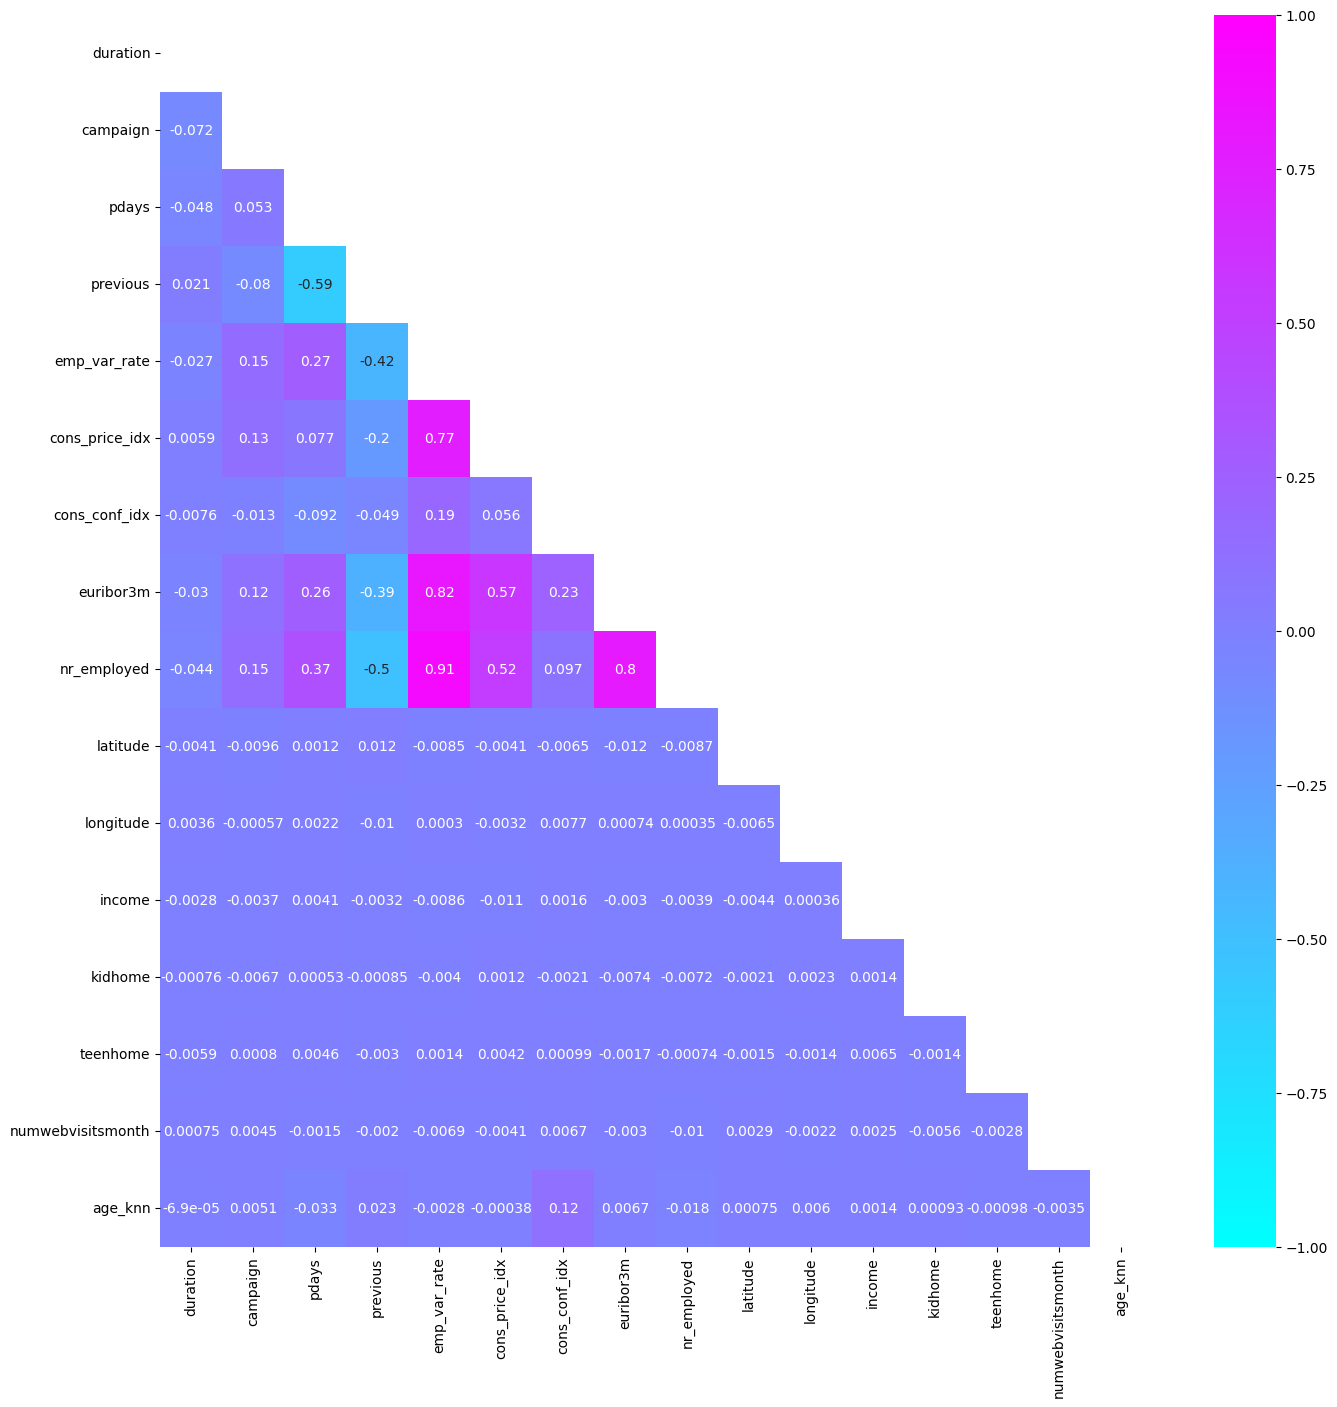

In [8]:
sv.matriz_correlacion(df_no_nulos)

## Conclusiones matriz de correlación

- **pdays** Correlacion media/baja positiva con **nr_employed** y correlacion media negativa con **previous** 
- **previous** correlacion media negativa con **nr_employed** , **euribor3m**  y **emp_var_rate**
- **emp_var_rate** correlacion alta positiva con **nr_employed** , **euribor3m** y **cons_price_idx**
- **cons_price_idx** correlacion media positiva con **nr_employed** y **euribor3m**
- **euribor3m** correlacion alta positiva con **nr_employed**


- **pdays** podria tener sentido la relacion con **nr_employed** pero no tiene sentido la relacion con **previous** no podemos establecer una relacion con   
                    previous ya que esta se refiere a datos disntintos a los de la campaña actual
- **previous** no tiene sentido la relacion con **nr_employed**, **euribor3m**  y **emp_var_rate** ya que estos son datos durante la actual camapaña
- **emp_var_rate**:
                    -Tiene sentido tener una fuerte relacion con **nr_employed** si la tasa de variancion de empleo es positiva el numero de empleados sube
                    -Relacion positiva con **euribor3m**. Aunque pueda parecer contradictorio puede tener sentido en excenario de recuperacion economica. Cuando el empleo mejora los tipos de interes suben como medida contencion y cuando el empleo empeora los tipos se bajan como medida expansiva.
                    -Tiene sentido tener una fuerte Relacion positiva con **cons_price_idx**, al subir el empleo se incrementa el numero de personas con capacidad de adquisitiva y por tanto de consumo.
- **cons_price_idx**:
                    -Tiene sentido tener una relacion positiva con **nr_employed** ya que al aumentar el numero de empleos se incrementa la posibilidad de consumo y por tanto la tendencia alcista de los precios. Que sea una relacion media y no alta se puede deber a que hay mas factores que influyen en los movimientos de lod precios.Tiene sentido la relacion positiva con el **euribor3m** ya que al subir los precios, los tipos de interes suben como medida antiflacionista. Que sea una relacion media y no alta se puede deber a que hay mas factores que influyen en los movimientos del euribor.
- **euribor3m**:      
                    -Esta relacion alta positiva tiene sentido ya que cuando la    
                    economia crece, las empresas contratan, al contratar hay mas consumo, por tanto mayor inflacion y en consecuencia mayores politicas restrictivas como la subida de los tipos de interes.                  

## Mapa de ubicacion de clientes

In [9]:
df_lat_lon = df_no_nulos[(df_no_nulos['latitude'].isna() == False) & (df_no_nulos['longitude'].isna() == False)]
df_mapa = df_lat_lon.groupby(['latitude','longitude'])['numwebvisitsmonth'].sum().reset_index()

In [10]:
sv.mapa(df_mapa,'latitude','longitude','numwebvisitsmonth')

* Habria que consultar con el proveedor de los datos ya que parece haber un error en las coordenadas. Tratandose de un Banco Portugues cabe pensar que sus clientes sean de Portugal, pero el grafico muestra localizacion en Norteamerica. Ademas, la distribucion de los puntos es muy homogenea, incluso saliendose de el perimetro continental. Todo indica que se puede tratar de datos erroneos.

## FECHAS

### Evolucion de productos contratados

<Axes: xlabel='date_contact', ylabel='subscription_prod'>

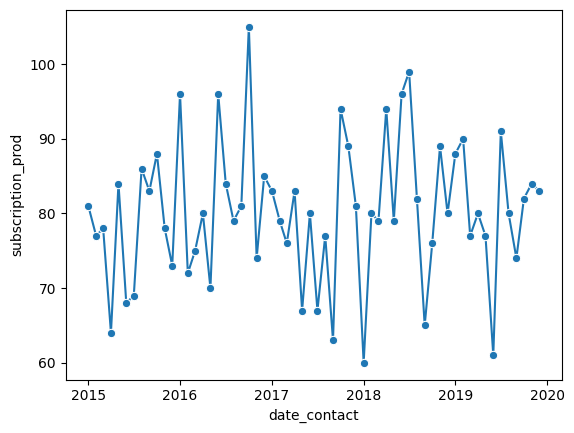

In [11]:
df_date_subs_prod = df_no_nulos[df_no_nulos['subscription_prod'] == 'yes'].groupby(df_no_nulos['date_contact'].dt.to_period('M'))['subscription_prod'].count().reset_index()
df_date_subs_prod['date_contact'] = df_date_subs_prod ['date_contact'].dt.to_timestamp()

sns.lineplot(x='date_contact', y = 'subscription_prod', data = df_date_subs_prod,
             marker = "o" )


*   La exitos de la campaña parecen concentrarse en torno a un 80 numero de subscripciones durante los distintos años.
*   Donde mas exito ha tenido ha sido en: Enero, Junio y Octubre de **2016**. En Octubre de **2017**. En Abril, Junio y Julio de **2018** y Julio de**2019**
*   Donde menos exito se ha tenido ha sido en: Abril, Junio y Julio de **2015**, en Mayo, Julio y Septiembre de **2017**, Enero y septiembre de **2018** y Junio de **2019**
                                        

## Estudio de variables correlacionadas

### emp_var_rate y nr_employed

<Axes: xlabel='emp_var_rate', ylabel='nr_employed'>

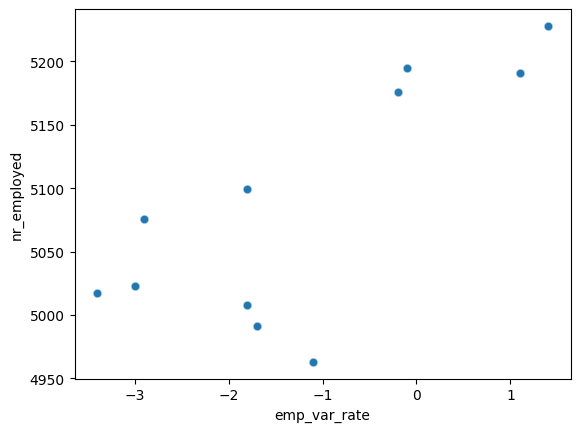

In [12]:
sns.scatterplot(x = "emp_var_rate", y="nr_employed", data = df_no_nulos, alpha = 0.25)

* El data frame tiene muschas filas con valores repetidos en las mismas combinaciones de emp_var_rate y nr_employed. Por eso no se ve una gran cantidad de puntos en el grafico. Exceptuando 3 de los puntos de emp_var_rate en general se ve una tendencia de que al desplazarse a la derecha los valores en nr_emplyed crecen

### emp_var_rate y euribor3m

<Axes: xlabel='emp_var_rate', ylabel='euribor3m'>

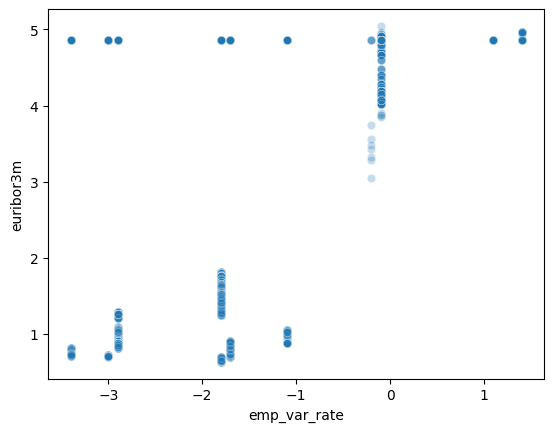

In [13]:
sns.scatterplot(x = "emp_var_rate", y="euribor3m", data = df_no_nulos, alpha = 0.25)

* Hay 3 o cuatro valores para los cuales cuando la tasa de empleo se mantuvo en un determinado valor, el euribor ha oscilado entre distitos valores. Esto puede ser consecuencia de que el Euribor, a pesar de verse afectado por la tasa de empleo, al mismo tiempo depende de otros facores.

### nr_employed y cons_price_idx

<Axes: xlabel='emp_var_rate', ylabel='cons_price_idx'>

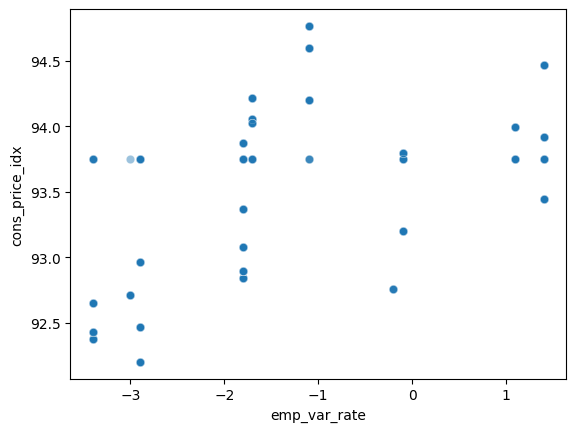

In [14]:
sns.scatterplot(x = "emp_var_rate", y="cons_price_idx", data = df_no_nulos, alpha = 0.25)

* Aqui podermos encontrar de nuevo no demasiados puntos ya que, de la misma manera que en los casos anteriores, hay unos pocos valores que se repiten. Quizas aqui estan algo mas dispersos por lo que para los distintos valores de la tasa de empleo el indice de precios de consumo ha variado un poco mas en cada punto. Si se puede apreciar una tendencia general de que al desplazarse a la derecha la tasa de empleo, el indice de precios de consumo tiende a ir creciendo tambien.

### COLUMNAS NUMERICAS

In [17]:
col_num = 'age_knn'
cols_num = df_no_nulos.select_dtypes(include='number').columns
cols_num

Index(['duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
       'latitude', 'longitude', 'income', 'kidhome', 'teenhome',
       'numwebvisitsmonth', 'age_knn'],
      dtype='object')

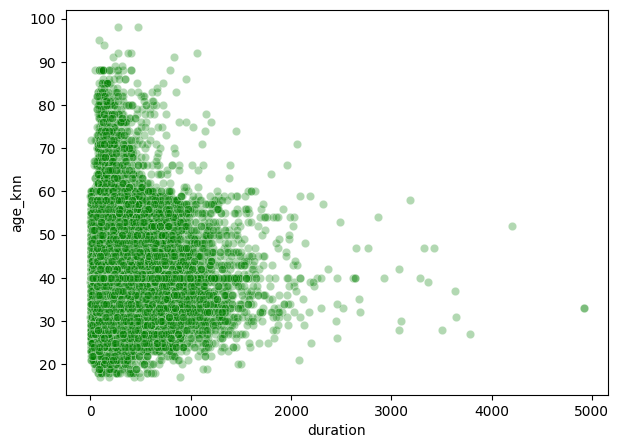

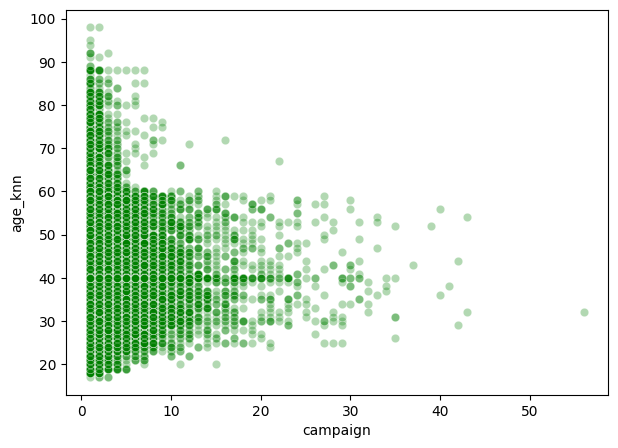

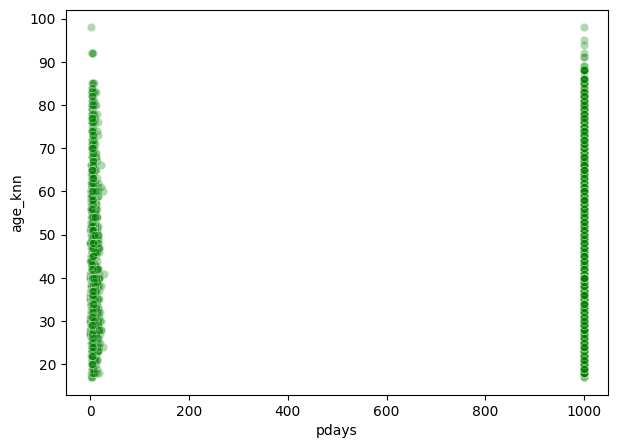

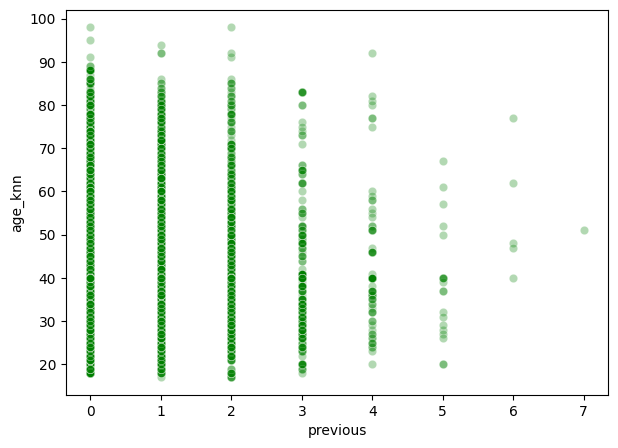

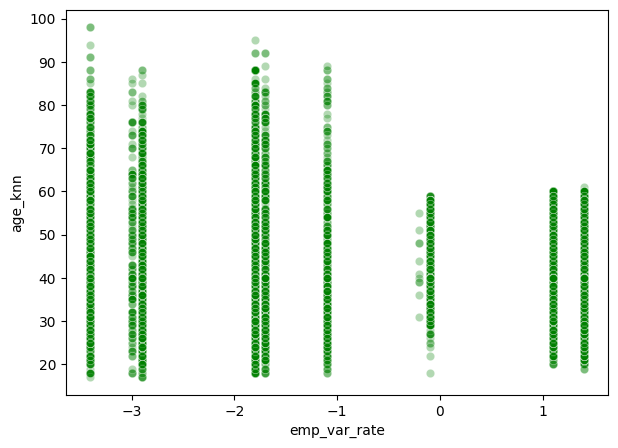

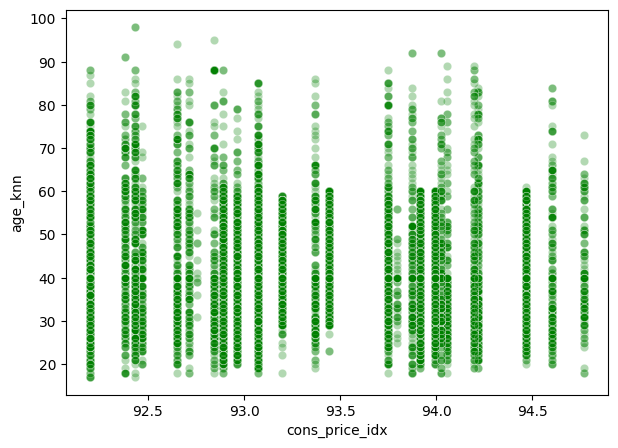

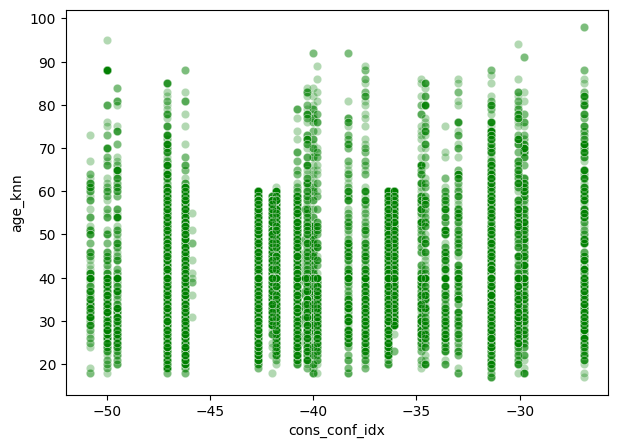

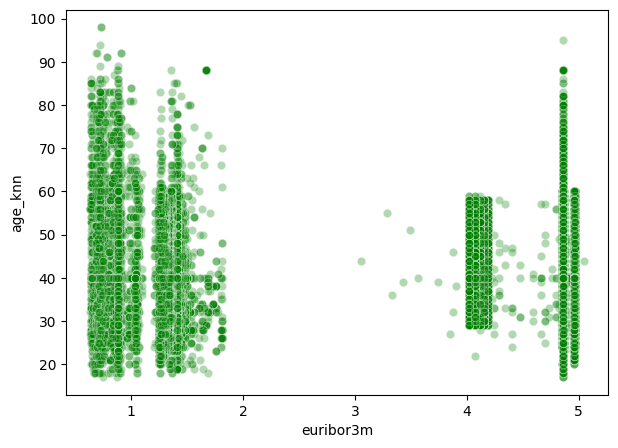

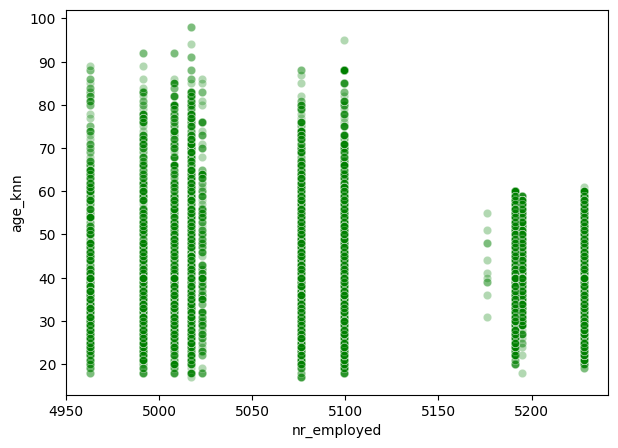

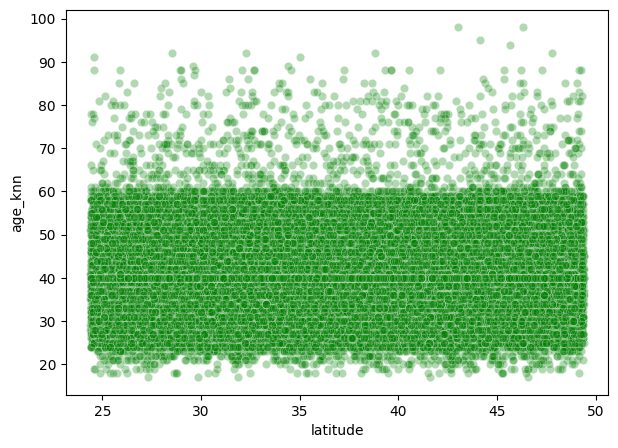

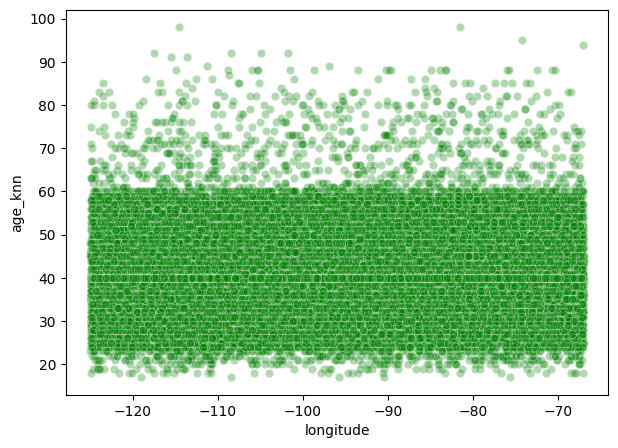

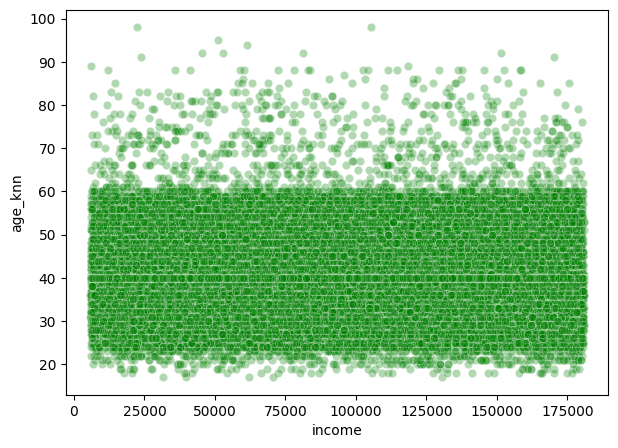

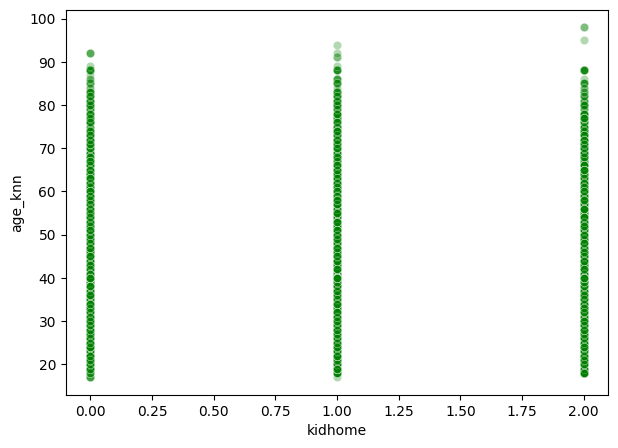

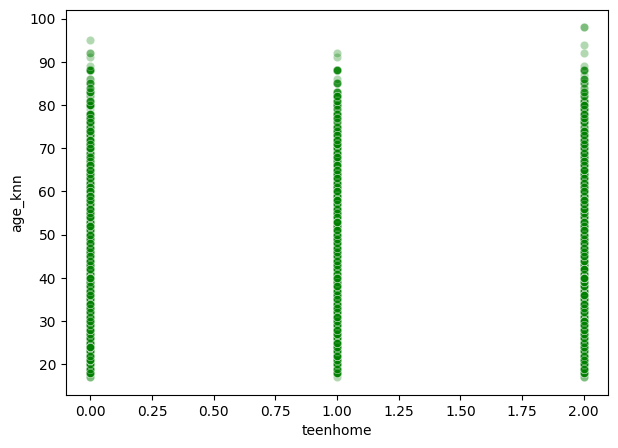

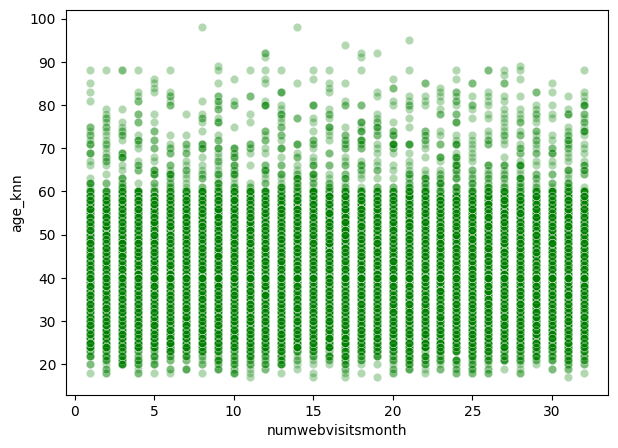

In [18]:
for col in cols_num:
    if col == col_num:
        continue
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_no_nulos, x= col, y=col_num, color= 'green', alpha= 0.3)
    #plt.yscale('log')
    plt.show()

## INTERPRETACION

### 1. DESCRIPCION DE LOS DATOS

* El dataset contiene información de 43,000 clientes contactados durante la campaña. Solo el 11.27% de los clientes aceptaron el producto, lo que significa que hay casi 8 veces más rechazos que aceptaciones. Esta diferencia tan grande entre respuestas positivas y negativas es importante tenerla en cuenta para el análisis.

* Los datos incluyen tres tipos principales de variables. Las variables demográficas describen quién es el cliente: edad, profesión, estado civil, educación e ingresos. Las variables de campaña describen cómo fue el contacto: duración de la llamada, número de intentos, días desde el último contacto. Las variables económicas reflejan la situación del país en ese momento: tasa de empleo, inflación, tipos de interés.

### 2. VARIABLES DEMOGRAFICAS

* El cliente típico tiene alrededor de 40 años, está casado y tiene educación universitaria o bachillerato. Las profesiones más comunes son administrativos, obreros y técnicos, que juntos representan el 64% de los contactados. Más de la mitad de los clientes tienen educación superior, lo que facilita que entiendan productos financieros complejos.

* La edad muestra una distribución normal con un pico en 39.97 años. Los outliers en edad corresponden a personas muy jóvenes o muy mayores.

* Los ingresos tienen una distribución uniforme, lo cual parece un tanto irreal. Las coordenadas geográficas también presentan problemas ya que corresponden a ubicaciones en Estados Unidos cuando el banco es portugués.

### 3. VARIABLES DE CAMPAÑA

* La duración promedio de las llamadas es de 4 minutos. La distribución está muy sesgada porque la mayoría de llamadas son cortas pero hay algunas muy largas que llegan hasta 83 minutos. Estas llamadas excepcionalmente largas representan el 7.14% del total y probablemente indican clientes muy interesados o con muchas dudas.

* El número de contactos por cliente suele ser de 2 o 3 intentos. Hay casos extremos donde se contactó a clientes más de 6 veces, lo que representa el 5.82% de los casos. Estos clientes podrían estar experimentando fatiga por exceso de contactos.

* La variable pdays: el 86.29% de los valores son 999, podria indicar que no hubo contacto. Siendo asi solo el 13.71% de los clientes habrian sido contactados en campañas anteriores. De estos clientes con contacto previo, solo el 3.34% habrían aceptado el producto en ocasiones anteriores.

### 4. VARIABLES ECONOMICAS

* Las cuatro variables económicas están muy relacionadas entre sí. La tasa de variación del empleo correlaciona 0.91 con el número de empleados, 0.82 con el euribor y 0.77 con el índice de precios. Esto significa que estas variables están midiendo básicamente lo mismo: el estado general de la economía.

* Cuando la economía va bien, hay más empleos, los tipos de interés suben y los precios suben. Cuando la economía va mal, pasa lo contrario.

* El euribor tiene dos grupos muy diferenciados que reflejan dos políticas monetarias distintas: tipos altos antes de la crisis y tipos muy bajos después.

### 5. ANALISIS DE CORRELACIONES

* Dado que hay varias variables economivas midiendo lo mismo a la hora de usarlas no seria necesario emplearlas todas.

* Las variables demográficas no presentan problemas de correlación entre ellas. Los ingresos, la edad, el número de hijos y las visitas web están prácticamente sin relación entre sí. 

* Curiosamente, el número de niños y el número de adolescentes en casa no correlacionan entre sí, lo que podria indicar que las familias tienden a tener niños pequeños o adolescentes pero no ambos al mismo tiempo.

### 6. OUTLIERS DETECTADOS

* Se encontraron outliers en varias variables pero la mayoría no son errores sino casos extremos reales. Las llamadas muy largas (7.14% de outliers) probablemente representan clientes muy interesados. Los clientes con muchos contactos previos (13.71% de outliers) son clientes veteranos del banco. Los clientes contactados muchas veces en la campaña actual (5.82% de outliers) podrían estar experimentando fatiga.

* No se han eliminado estos outliers porque estos valores extremos pueden corresponderse a clientes que tienen más o menos probabilidad de aceptar el producto.

### 7. DISTRIBUCIONES IRREALES

* Los ingresos están perfectamente uniformes cuando normalmente deberían concentrarse en rangos medios-bajos. Las visitas web también están uniformemente distribuidas cuando lo normal sería que pocos clientes visitaran mucho y muchos clientes visitaran poco.

### 8. DIFICIL CORRELACION CON "subscription_pro"

*  Solo el 11.27% de los casos son aceptaciones y el 88.73% son rechazos. Esto crea un problema importante para crear modelos predictivos.

### 9. CONCLUSIONES Y RECOMENDACIONES

* Primero, las variables económicas están muy correlacionadas y solo debemos usar una o dos en futuros analisis.
* Desbalanceo de clases severo. 
* Las variables demográficas aportan información única sin problemas de correlación/sobreinformacion. 
* La mayoría de outliers son casos extremos informativos que no deberian eliminarse.
* Hay indicios de problemas de calidad en algunas variables como ingresos y coordenadas geográficas.



* Desde el punto de vista comercial, el análisis sugiere varias estrategias. 
* Enfocar los esfuerzos en administrativos, obreros y técnicos que representan casi dos tercios del mercado. 
* Usar preferentemente el canal de teléfono móvil que representa el 63.71% de los contactos. 
* Limitar el número de intentos a 5 como máximo para evitar saturar al cliente.
* Aprovechar que el 86.29% de clientes nunca fueron contactados antes, lo que representa una oportunidad de primera impresión. 
* Considerar el contexto económico porque las campañas en periodos de recuperación económica probablemente tengan mejor resultado.